# makemore_batchnorm


## preparation

We'll continue optimizing the code from the previous lesson.

I will use multi-line comments to annotate the optimization notes and code for this lesson.

In [1]:
# import module
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read file
words = open('../names.txt', 'r').read().splitlines()

In [3]:
# utility functions
from string import ascii_lowercase
stoi = {c:i+1 for i, c in enumerate(ascii_lowercase)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos)

In [4]:
# build and split the dataset
block_size = 3

def build_dataset(words):  
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])    # 10% dev set
Xte, Yte = build_dataset(words[n2:])        # 10% test set

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [33]:
# MLP
g = torch.Generator().manual_seed(2147483647)

emb_dim = 10    # dimension of embedding vectors
ns_num_h = 200    # the number of neurons in hidden layer

"""
Fixing the Initial Loss (marked with `L` below)
(fix softmax confidently wrong)

Scale down output layer weights/biases near 0 to fix the artificially high initial loss.
Without this, standard normal init causes extreme logits (loss ~27). 
Scaling drops the initial loss to ~3.3 (since we have 27 characters, a uniform distribution 
yields an expected initial loss of exactly -log(1/27) ≈ 3.3). This saves early epochs 
from merely squashing weights and allows the model to focus on meaningful learning immediately.

Note on leaf vs. non-leaf nodes:
Leaf nodes have gradients (`.grad`) but no gradient function (.grad_fn).
Non-leaf nodes have a gradient function but do not retain gradients. 
Therefore, we update parameters via `tensor.data` to perform in-place operations 
without breaking the autograd computation graph.
"""
"""
Preventing Dead Neurons (marked with `D` below)
(fix tanh layer woo saturated at init)

Because we use `tanh` in hidden layer,
its derivative is close to 0 as inputs approach infinity (|x| >= 3).
If initial W1 and B1 are too large, pre-activations blow up and gradients drop to near zero. 
When this happens, the neuron permanently stops updating during gradient descent (it "dies").
We fix this by scaling down W1 and B1 to keep initial values close to 0.

Note: An excessively high learning rate during training can also knock parameters 
far off the data manifold, leaving neurons permanently inactive (dead) because 
no training samples will ever hit them.
"""
"""
Xavier Initialization (Karpathy loosely calls it "Kaiming init")  (marked with `X` below)

`X @ W1` scales variance by `fan_in`, risking activation explosion.
Fix: Scale std to 1/sqrt(fan_in) to maintain input/output variance.
Gain: Multiply by 5/3 to compensate for the `tanh` squashing effect ("semi-principled").
Note: True Kaiming (2015) uses sqrt(2/fan_in) to offset ReLU's 50% dead zone. 
Without the sqrt(2) and paired with `tanh`, this belongs to the Xavier family.
"""
C = torch.randn((vocab_size, emb_dim),             generator=g, requires_grad=True)
W1 = torch.randn((block_size * emb_dim, ns_num_h), generator=g, requires_grad=True)
# W1.data *= 0.1    # D
W1.data *= (5/3) / (block_size * emb_dim)**0.5    # X
B1 = torch.randn(ns_num_h,                         generator=g, requires_grad=True)
B1.data *= 0.01    # D
W2 = torch.randn((ns_num_h, vocab_size),           generator=g, requires_grad=True)
W2.data *= 0.01    # L
B2 = torch.randn(vocab_size,                       generator=g, requires_grad=True)
B2.data *= 0    # L
parameters = [C, W1, B1, W2, B2]

print(sum(p.numel() for p in parameters))

11897


In [34]:
# use training set to train model
max_steps = 200000
batch_size = 32
lossi = []

for k in range(max_steps):
    
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    hpreact = emb.view(-1, block_size * emb_dim) @ W1 + B1
    hl = torch.tanh(hpreact)
    logits = hl @ W2 + B2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += p.grad * -(lr := 0.1 if k < 100000 else 0.01)

    # monitor
    if k % 10000 == 0:
        print(f'{k:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

      0/ 200000: 3.2909
  10000/ 200000: 2.3594
  20000/ 200000: 2.4792
  30000/ 200000: 2.1567
  40000/ 200000: 2.5115
  50000/ 200000: 2.0599
  60000/ 200000: 2.0668
  70000/ 200000: 2.0928
  80000/ 200000: 2.3785
  90000/ 200000: 1.9158
 100000/ 200000: 1.9762
 110000/ 200000: 1.8842
 120000/ 200000: 2.1024
 130000/ 200000: 2.2311
 140000/ 200000: 1.9367
 150000/ 200000: 2.2948
 160000/ 200000: 1.7643
 170000/ 200000: 1.7147
 180000/ 200000: 2.0316
 190000/ 200000: 2.1307


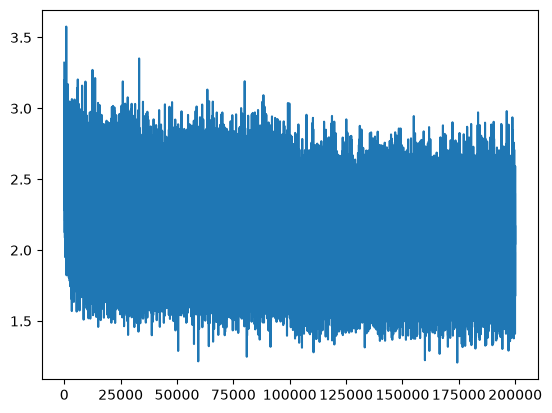

In [31]:
plt.plot(lossi)

In [35]:
# evaluate the model and adjust hyperparameters
@torch.no_grad()
def splits_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
    logits = hl @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(f"{split}: loss: {loss:.4f}")
    return loss

tr_loss = splits_loss('train')
dev_loss = splits_loss('dev')

train: loss: 2.0382
dev: loss: 2.1045


**loss log**

**original**:
train 2.1126
val   2.1549

**fix softmax confidently wrong**:
train 2.0701
val   2.1274

**fix tanh layer too saturated at init**:
train 2.0590
val   2.1085

**Xavier init**
train 2.0382
val   2.1045

In [7]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():
    for _ in range(10):
        outs = []
        context = [0] * block_size
        while True:
            emb = C[torch.tensor([context])]
            hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
            logits = hl @ W2 + B2
            probs = torch.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g)
            outs.append(itos[ix.item()])
            context = context[1:] + [ix]
            if ix == 0: break
        print(''.join(outs))

carpa.
fatifil.
khyir.
shreet.
khalaysa.
jazonte.
delynn.
jareen.
nellara.
chaihvik.
